# Lindsey Prochot: S&DS 1230 Final Project <br> Global Cost and Affordability of Healthy Diets

## Introduction 
**Research questions**: <br>
     My report seeks to analyze the different factors that play a role in affordability of a healthy diet. It considers geography, and how the affordability of healthy diets differs both across continents and within continents. My report also focuses on the effect of food type on cost, with the data grouped into six major food groups: 1. Animal Source Foods (more commonly called proteins), 2. Fruits, 3. Legumes, nuts and Seeds, 4. Oils and Fats, 5. Starchy Staples, and 6. Vegetables. While looking at these groups, driving questions include: How do cost breakdowns compare across food categories? To what extent is food accessibility a supply issue as opposed to an income one? Analyzing the costs of healthy diets is important to understanding greater nutrition and health across the world. Unaffordable healthy foods are the root cause of malnutrition in some countries, and obesity in others. Understanding where unaffordability stems from—scarcity or economic policy—is the first step to formulating a solution for these issues.

**Data Sourcing**: <br>
The data on healthy diets is from the World Bank Group, which includes the average cost and affordability of a healthy diet (CoAHD), as well as costs of specific food groups, for individual countries  : https://data360.worldbank.org/en/dataset/FAO_CAHD <br>
The global food supply data comes from the Food and Agriculture Organization of the UN (FAO). I filtered the database on their website to include only the relevant food groups and supply metrics before downloading it: https://www.fao.org/faostat/en/#data/FBS <br>
These other data sets were used for visualization purposes: <br>
Source of data to match every country in the dataset with its continent: https://www.kaggle.com/datasets/hserdaraltan/countries-by-continent?resource=download <br>
Source of data to match every country in the dataset with its population: https://databank.worldbank.org/embed/2021-Population-Data/id/67b1e32b <br>
Source of data to match every country in the dataset with its geographical coordinates: https://www.naturalearthdata.com/downloads/10m-cultural-vectors/

**Similar Analyses Utilizing this Data**: <br>
The World Bank group has utilized its "Cost of a Healthy Diet" (CoAHD) to create choropleth maps of the world showing costs for each category of food. My choropleth maps are very similar, but mine visualize percentiles instead of gross amounts, and I have also created additional choropleth graphs that map food supplies. A list of the World Bank maps can be found here: https://data360.worldbank.org/en/search?database=FAO_CAHD&tab=indicator <br>
The FAOSTAT dataset is extremely large, and so a variety of indicators can be found across many years. They are grouped by country here: https://www.fao.org/faostat/en/#country. None of the ones that I have seen thus far analyze the relationship between food supply and cost. 



## Data wrangling: Preparation for Visualization
Please note that the remaining data wrangling occurs throughout the report, as the data needed to be transformed in various ways for each visualization. 
### Step 1: Import Packages

In [1]:
import YData
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import geopandas as gpd
import matplotlib.patches as mpatches





### Step 2: Importing and Reformatting the CoAHD Data

In [2]:
wide_diet_data = pd.read_csv("healthy_diet_data_wide.csv")
wide_diet_data=wide_diet_data.drop(columns=["FREQ", "FREQ_LABEL",
        "OBS_CONF", "OBS_CONF_LABEL", "DATABASE_ID","DATABASE_ID_LABEL",
        "OBS_STATUS", "OBS_STATUS_LABEL", "2017", "2018", "2019",
        "2020", "2022", "2023", "2024"])
##Creating a dataframe (PPP_wide_diet_data) that keeps only rows with data in PPP dollars 
domestic_currency_mask=wide_diet_data.UNIT_MEASURE_LABEL=="Domestic currency per person per day"
domestic_currency_indices=[]
for i in range(len(domestic_currency_mask)):
    if domestic_currency_mask[i]==True:
        domestic_currency_indices.append(i)
PPP_wide_diet_data=wide_diet_data.drop(domestic_currency_indices)


## Figure 1: Median Worldwide Cost per Healthy Food Category
For figures 1 and 2, please note that a "PPP dollar" is a theoretical dollar that accounts for differences in the value of currency ("purchasing power parity") across the world, allowing for more accurate comparisons. 

In [ ]:
##Creating a dataframe (general_grouped_data) that groups the data on food costs and affordability by country, sorted alphabetically
general_grouped_data=PPP_wide_diet_data.pivot_table(index="REF_AREA_LABEL", columns="INDICATOR_LABEL", values="2021")
general_grouped_data=general_grouped_data.rename(index={"Viet Nam":"Vietnam", "Bahamas, The": "Bahamas",
                                                        "Congo, Rep.":"Congo", "Congo, Dem. Rep.":"Democratic Republic of Congo",
                                                        "Brunei Darussalam":"Brunei", "Burkina Faso": "Burkina", "Cabo Verde":"Cape Verde",
                                                       "Egypt, Arab Rep.":"Egypt", "Gambia, The":"Gambia", "Hong Kong SAR, China":"Hong Kong",
                                                        "Korea, Rep.":"South Korea", "Iran, Islamic Rep.":"Iran","Kyrgyz Republic":"Kyrgyzstan",
                                                        "Lao PDR":"Laos", "Russian Federation":"Russia", "Slovak Republic":"Slovakia",
                                                        "St. Kitts and Nevis":"Saint Kitts and Nevis", "St. Lucia":"Saint Lucia",
                                                        "St. Vincent and the Grenadines":"Saint Vincent and the Grenadines",
                                                       "Syrian Arab Republic":"Syria", "Taiwan, China":"Taiwan","Turkiye":"Turkey"})
general_grouped_data=general_grouped_data.sort_values(by="REF_AREA_LABEL")

##Creating a dataframe (food_category_comparisons) that aggregates across countries the median cost per food category
food_category_comparisons=general_grouped_data.drop(columns=["Cost of a healthy diet (PPP dollar per person per day)",
                                           "Number of people unable to afford a healthy diet (million)",
                                           "Percentage of the population unable to afford a healthy diet (percent)"])
food_category_comparisons=food_category_comparisons.agg(["median"]).T
rename_dictionary={"median": "Median"}
food_category_comparisons=food_category_comparisons.rename(columns=rename_dictionary)
rename_dictionary_rows=["Animal Source Foods", "Fruits", "Legumes, nuts and seeds", "Oils and Fats", "Starchy staples", "Vegetables"]
food_category_comparisons.index=rename_dictionary_rows


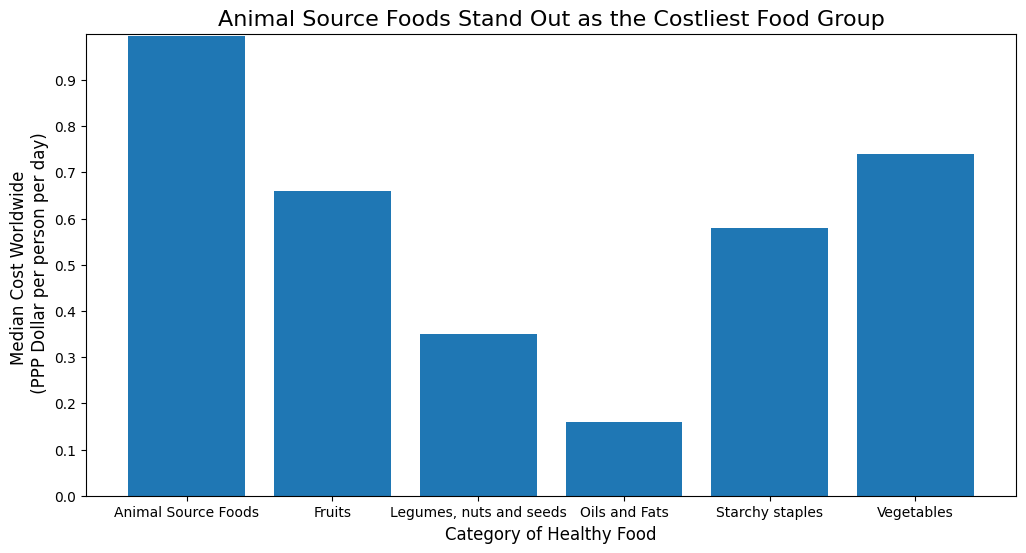

In [5]:
plt.figure(figsize=(12, 6))
plt.bar(food_category_comparisons.index, food_category_comparisons.Median);
plt.yticks(np.arange(0, 5, 0.5)) 
plt.xlabel("Category of Healthy Food", fontsize=12)
plt.ylabel("Median Cost Worldwide \n (PPP Dollar per person per day)",fontsize=12)
plt.title("Animal Source Foods Stand Out as the Costliest Food Group", fontsize=16) 
plt.ylim(0, 1)
plt.yticks(np.arange(0, 1, .1))
plt.show()


&nbsp;By far, animal source foods are the most expensive category of healthy food, while oils and fats are extremely low-cost. From this graph, one can guess that **processing costs** factor heavily into the final cost of food. Animal source foods, fruits, and vegetables are likely the most expensive categories of food worldwide because foods within this category incur many costs from harvesting and production. I think it is also noteworthy that the lowest cost goods are **nonperishables**, and transportation and distribution of nonperishable foods is logistically much simpler. Let us now see whether these cost relationships look the same when dissected by continent.

## Figure 2: Healthy Diet Cost Breakdowns per Continent

In [ ]:
## See Appendix 1.1 for how countries were sorted into the appropriate continents

<function matplotlib.pyplot.show(close=None, block=None)>

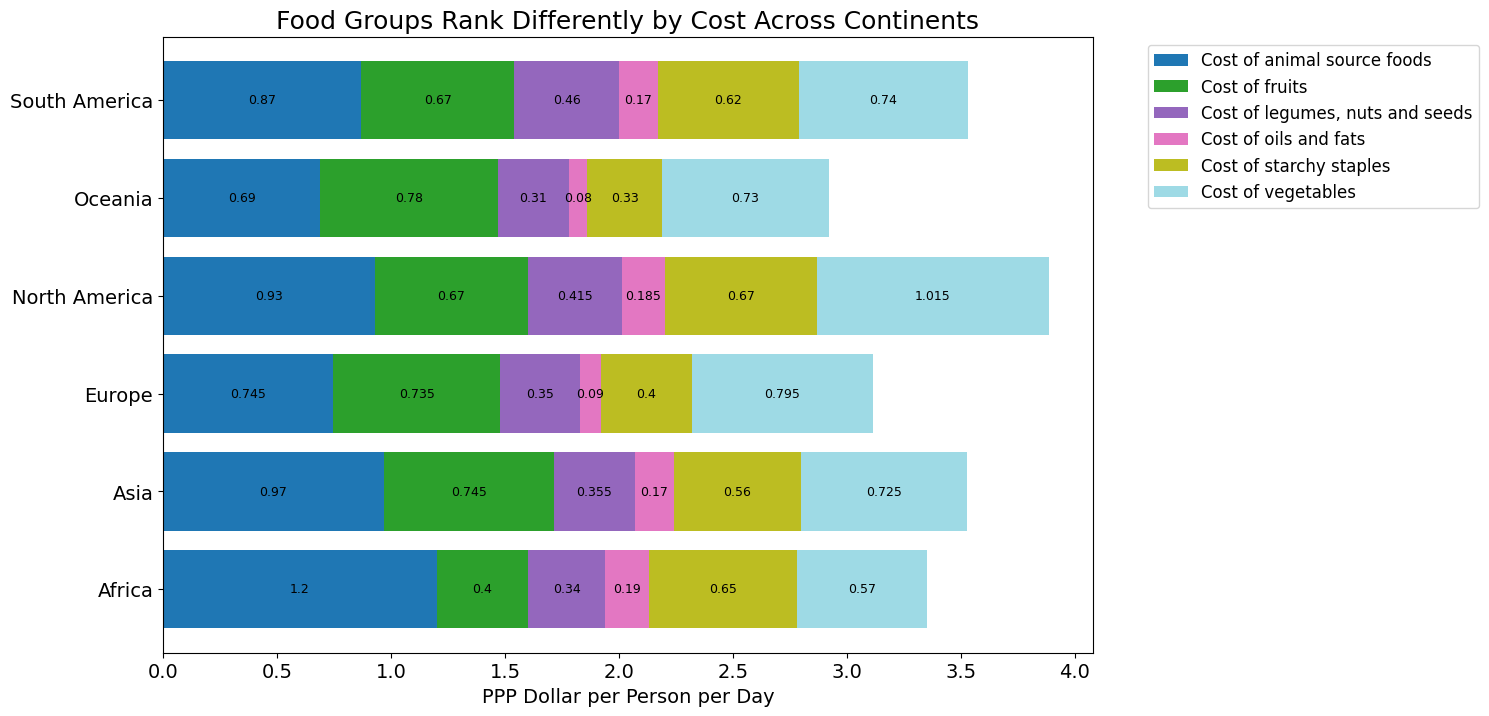

In [6]:
food_categories_stacked=food_categories_data.groupby("Continent").agg("median")
ax=food_categories_stacked.plot(kind='barh', stacked=True, figsize=(12, 8), width=0.8, fontsize=14,colormap="tab20")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
for container in ax.containers:
    ax.bar_label(container,label_type='center', color='black', fontsize=9,)
plt.xlabel("PPP Dollar per Person per Day", fontsize=14)
plt.title("Food Groups Rank Differently by Cost Across Continents", fontsize=18)
plt.ylabel("")
plt.show

&nbsp;From the stacked bar chart, it can be seen that processing costs **are not the sole factor** controlling food prices. If they were, animal source foods would be the most expensive category of food across every continent, which is not the case. Although animal-source foods, fruits, and vegetables are remain the three costliest food groups, their order varies by region. For example, in Oceania, animal source foods are actually cheaper than fruits and vegetables, whereas in Africa, they cost twice as much. This variation in relative prices across continents suggests that geography and other contextual factors also play important roles in shaping costs of healthy food.  The next visualization introduces one of these possible other variables: global food supplies.

## Figure 3: Global Food Supplies 
The units “Kilograms per Capita per Year” represent the annual supply of each food group, measured as kilograms available per person in a given country. For each continent, these country-level values were aggregated using the median.

In [ ]:
##Creating a new dataframe (supply_data_pivot) that is used for the heatmap, chloropleth map and hypothesis test
##This dataframe has rows of country names and many columns of food supplies by type of food
supply_data=pd.read_csv("new_supply_data.csv")
supply_data = supply_data.fillna(0).drop(index=0).reset_index()
supply_data.columns=["index","REF_AREA_LABEL", "Units", "Food category", "Value"]
supply_data=supply_data.drop(columns={"index"})
supply_data["Value"] = pd.to_numeric(supply_data["Value"], errors="coerce")
supply_data_pivot=supply_data.pivot_table(index="REF_AREA_LABEL", columns="Food category", values="Value")
supply_data_pivot=supply_data_pivot.drop(index=0)
supply_data_pivot=supply_data_pivot.drop(supply_data_pivot.columns[0], axis=1)

##Creating a dataframe (new_blank_supply_df) which will contain rows of country names
##It will also have 6 columns of food supplies, with the food types from supply_data_pivot having been sorted into 6 categories 
column_names=["Country Name", "Category", "Value"]
category_names=["Animal Source Foods Supply", "Fruits Supply", "Legumes, nuts and seeds Supply",
                "Oils and Fat Supply", "Starchy staples Supply", "Vegetables Supply"]
new_blank_supply_df=pd.DataFrame()


In [ ]:
## See Appendix 1.2 for how the dataframe new_blank_supply_df was filled with food supply data and sorted into the 
## appropriate categories

Text(0.5, 1.0, 'Food Supply Patterns Help Explain \n Food Group Pricing Across Continents')

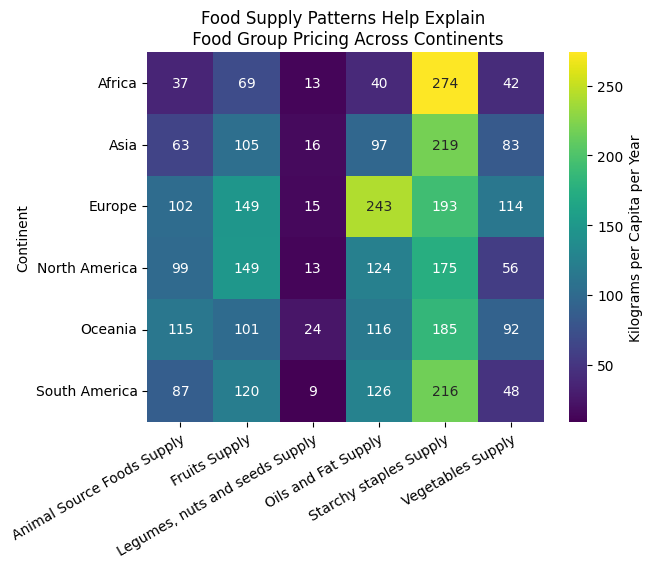

In [7]:
##Creating a dataframe (heatmap_grouped_by_continent) that has the supply for each category in each continent
heatmap_data=scatter_plot_data.merge(new_blank_supply_df, how="inner", left_on="REF_AREA_LABEL", right_index=True)
heatmap_data=heatmap_data.drop(columns=["Cost of a healthy diet (PPP dollar per person per day)", "Cost of animal source foods",
                                        "Cost of fruits", "Cost of legumes, nuts and seeds", "Cost of oils and fats",
                                        "Cost of starchy staples", "Cost of vegetables",
                                        "Number of people unable to afford a healthy diet (million)",
                                        "Percentage of the population unable to afford a healthy diet (percent)", "Total Population", 
                                        "REF_AREA_LABEL", "Country Code", "Color"])
heatmap_grouped_by_continent=heatmap_data.groupby("Continent").agg("median")
ax = sns.heatmap(heatmap_grouped_by_continent, annot=True, fmt=".0f", cmap="viridis",
                 cbar_kws={"label": "Kilograms per Capita per Year"})
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor");
plt.title("Food Supply Patterns Help Explain \n Food Group Pricing Across Continents", fontsize=12)

&nbsp;     This heatmap is useful in combination with the stacked bar graph to investigate how food supplies in continents relate to their median food costs. It generally seems that continents with **lower supplies** of a type of food tend to have a **higher median cost** for it. For example, South America has the lowest supply of starchy staples, and from the stacked bar chart, the highest median cost. The same can be said for Africa with animal source foods. The reverse can also be seen, with Oceania having the highest supply of animal source foods and the lowest cost. However, there seems to be diminishing returns for how much reduction in cost each additional unit of supply brings. Europe, for example, has more than double the oil and fats supply of any other continent. However, as can be seen in Figure 2, its median cost for oils and fats is already so low that it cannot become much cheaper. <br>
&nbsp;    One data point on this graph that doesn't make much sense is the 274 kilograms/capita/day of starchy staples in Africa. In this particular instance, although this supply is very high, there doesn't seem to be an effect on cost. Overall, however, it seems that **there is a pattern between the amount of a food** type a continent has in supply **and how high a price it pays** for that type. Through the use of choropleth maps and hypothesis testing, we can measure truly how strong the correlation between supply and cost is. 

## Figures 4.1-4.12 Mapping Worldwide Supply and Cost Percentiles per Food Category 
The maps below use percentiles to represent each country’s food supply and cost levels because they make it easier to see the significance of the value of a country relative to the world. Without this approach, a single country with an unusually high value could dominate the color scale and make meaningful differences among other countries harder to see. <br>
**Please note that the labeling is horizontal (ex. 4.1 is uppermost left, 4.2 is uppermost right)**

In [ ]:
##This is a function to make percentiles, used for the choropleth maps and hypothesis test
def make_percentile_column(og_column, my_df):
    my_df[og_column] = my_df[og_column].fillna(0)
    my_df[og_column + " percentile"] = my_df[og_column].rank(pct=True) * 100
    return my_df.head()


general_grouped_data2=PPP_wide_diet_data.pivot_table(index="REF_AREA_LABEL", columns="INDICATOR_LABEL", values="2021")
food_costs_percentiles_df=general_grouped_data2.drop(columns=["Cost of a healthy diet (PPP dollar per person per day)",
                                                             "Number of people unable to afford a healthy diet (million)",
                                                             "Percentage of the population unable to afford a healthy diet (percent)"])

##Creating a dataframe (supply_percentiles_df)
##This dataframe has the percentile of each country's food costs per category compared to the rest of the world
cost_columns = ["Cost of animal source foods","Cost of fruits","Cost of vegetables","Cost of oils and fats",
    "Cost of starchy staples","Cost of legumes, nuts and seeds"]
for col in cost_columns:
    make_percentile_column(col, food_costs_percentiles_df)
                                                               
##Creating a dataframe (supply_percentiles_df)
##This dataframe has the percentile of each country's food supplies per category compared to the rest of the world
supply_percentiles_df=new_blank_supply_df.copy()
supply_columns = ["Animal Source Foods Supply","Fruits Supply","Legumes, nuts and seeds Supply",
    "Oils and Fat Supply","Starchy staples Supply","Vegetables Supply"]
for col in supply_columns:
    make_percentile_column(col, supply_percentiles_df)

##Creating a dataframe (merged_percentiles) that combines supply and cost percentiles per country per food category
merged_percentiles=supply_percentiles_df.merge(food_costs_percentiles_df, how="inner", left_index=True, right_index=True)
merged_percentiles=merged_percentiles[["Animal Source Foods Supply percentile", "Cost of animal source foods percentile",
                                       "Fruits Supply percentile", "Cost of fruits percentile", 
                                       "Legumes, nuts and seeds Supply percentile", "Cost of legumes, nuts and seeds percentile",
                                       "Oils and Fat Supply percentile", "Cost of oils and fats percentile",
                                       "Starchy staples Supply percentile", "Cost of starchy staples percentile",
                                       "Vegetables Supply percentile", "Cost of vegetables percentile"]]

In [ ]:
##See Appendix 1.3 for how individual dataframes per food category were made 

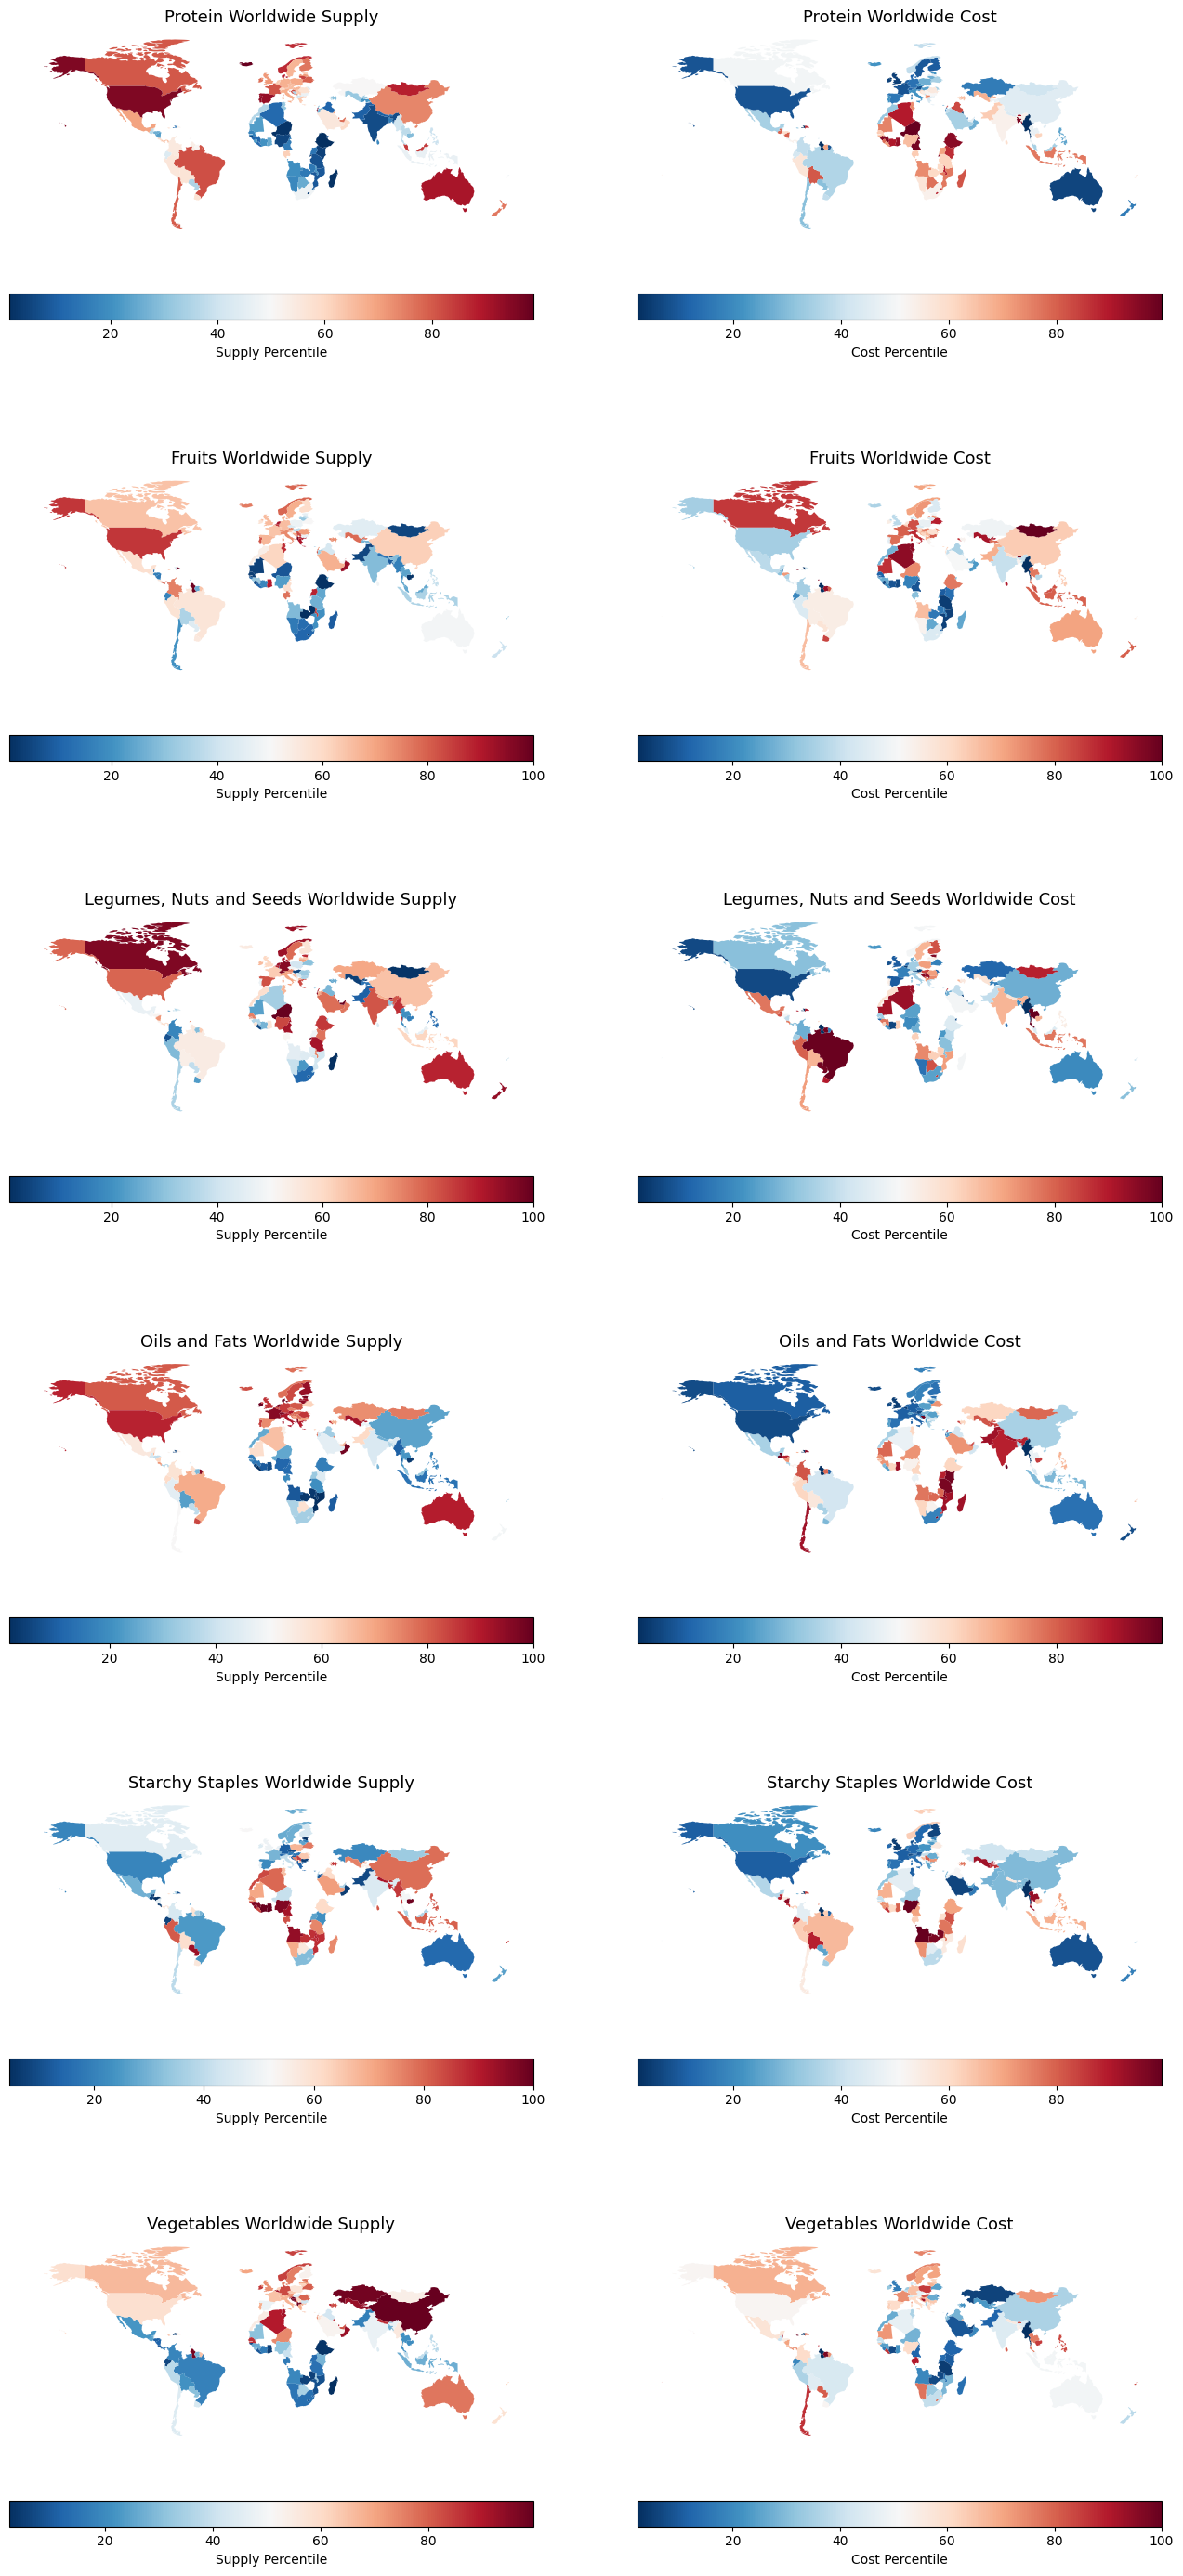

In [8]:
categories = [("Protein", protein_choropleth_geodata),("Fruits", fruits_choropleth_geodata),
    ("Legumes, Nuts and Seeds", legumes_choropleth_geodata),("Oils and Fats", fats_choropleth_geodata),
    ("Starchy Staples", starches_choropleth_geodata),("Vegetables", vegetables_choropleth_geodata)]
fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(16, 36))
axes = axes.flatten() 
for i, (category, gdf) in enumerate(categories):
    gdf.plot(column="Supply Percentile", cmap="RdBu_r", legend=True,
             legend_kwds={'label': "Supply Percentile", 'orientation': "horizontal"},ax=axes[2*i])
    axes[2*i].set_title(f"{category} Worldwide Supply", fontsize=13)
    axes[2*i].set_axis_off()

    gdf.plot(column="Cost Percentile",cmap="RdBu_r",legend=True,
        legend_kwds={'label': "Cost Percentile", 'orientation': "horizontal"},ax=axes[2*i + 1])
    axes[2*i + 1].set_title(f"{category} Worldwide Cost", fontsize=13)
    axes[2*i + 1].set_axis_off()
plt.show()

&nbsp;These choropleth maps allow for direct comparison of the supply and cost of healthy foods in individual countries, and they more concisely show for which categories of food this relationship is strongest. Key patterns from the choropleth maps:
+ There does not seem to be a strong relationship between supply and cost for fruits, starchy staples, and vegetables. Countries with low supplies still pay low prices. <br> 
+ Animal source foods seem to be a category in which supply is paramount for determining cost; the colors in the paired maps are very close to being directly inverse of each other. The same can be seen for legumes, nuts, and seeds. Oils and fats also strongly display this, with China being the main exception of having low supply but also low costs.<br>

I believe that a stronger correlation can be seen in these three categories because they are high supply in the more economically developed continents: North America, Europe, and Oceania. With better trade networks and technology, these regions are better positioned to **leverage comparative advantages** and convert abundant supply into lower domestic prices. Africa has the most supplies of starchy staples by far, but the correlation of this supply to lower costs is not present. In choropleth map 4.10, starchy staples still have a high cost percentile in Africa. The visualizations suggest that in less economically developed continents, which are characterized by inefficient infrastructure, unstable policy, and minimal international trade influence, resource abundance alone is **insufficient to reduce food prices.** Now let us generalize, taking into account developed and non-developed countries, the correlation between global food supply and cost percentiles.

## Analysis 1: Supply and Cost Percentiles - Correlation Across All Food Categories

In [ ]:
##Creating a dataframe (stacked_df) that combines all of the individual food category dataframes vertically
#I do this and then reset the index so you don't know which food category the row came from 
#I do this so I can conduct a hypothesis test of the relationship between supply percentiles and cost percentiles across food categories
stacked_df = pd.concat([protein_df, fruits_df, legumes_df, fats_df, starches_df, vegetables_df], axis=0).reset_index(drop=True)

#This null distribution assumes that there is no relationship between supply percentiles and cost percentiles.
null_dist = []

for i in range(10000):  
    shuff_stat = statistics.correlation(stacked_df["Supply Percentile"], np.random.permutation(stacked_df["Cost Percentile"]))
    null_dist.append(shuff_stat)


**Null hypothesis:** There is no correlation between food supply percentiles and food cost percentiles. <br>
**Alternative hypothesis:** There is a correlation between food supply percentiles and food cost percentiles. <br>
$H_0$: $\rho=0$ <br>
$H_A$: $\rho{\neq}0$

In [9]:
sample_correlation=statistics.correlation(stacked_df["Supply Percentile"], stacked_df["Cost Percentile"])
print(sample_correlation)

-0.18761403510697422


In [10]:
#Here is an example of what a correlation taken from the null distribution might look like
statistics.correlation(stacked_df["Supply Percentile"], np.random.permutation(stacked_df["Cost Percentile"]))

np.float64(-0.026594439628116886)

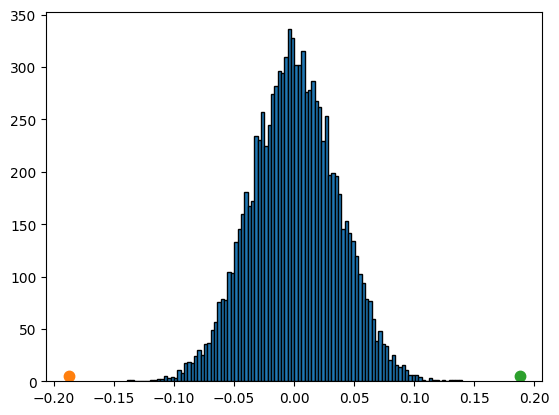

In [11]:
plt.hist(null_dist, edgecolor="k", bins=100);
plt.plot(sample_correlation, 5, ".", markersize=15)
plt.plot(-sample_correlation, 5, ".", markersize=15)

In [12]:
p_value1 = np.mean(np.array(null_dist)<= sample_correlation)
p_value2= np.mean(np.array(null_dist)>= (-sample_correlation))
p_value=p_value1+p_value2
p_value

np.float64(0.0)

&nbsp;In order to create this null distribution, I created a comprehensive table of cost and supply percentile pairs, that includes all food categories of all countries. After shuffling the order of the cost and supply percentile columns, I was able to create a null distribution and plot the calculated sample correlation of -.18. My p-value of this sample statistic after adding up the individual p-values from each end of the bell curve was 0. It is almost impossible that a correlation of -.18 or .18 could be obtained solely by chance. Thus, it is possible to reject the null hypothesis and conclude there is a relationship between a country's supply percentile of a food and its cost percentile for that food. 

## Analysis 2: Top 10 Countries Where Healthy Diets are Most Unaffordable

In [ ]:
##Creating a dataframe (most_costly) of the ten countries where food is most expensive
most_costly=general_grouped_data.sort_values("Cost of a healthy diet (PPP dollar per person per day)", ascending=False)
most_costly=most_costly[["Cost of a healthy diet (PPP dollar per person per day)",
                                 "Percentage of the population unable to afford a healthy diet (percent)"]]
most_costly=most_costly.reset_index()


##Creating a dataframe (most_unaffordable) of the ten countries where food is most unaffordable
most_unaffordable=general_grouped_data.sort_values("Percentage of the population unable to afford a healthy diet (percent)", ascending=False)
most_unaffordable=most_unaffordable[["Cost of a healthy diet (PPP dollar per person per day)",
                                 "Percentage of the population unable to afford a healthy diet (percent)"]]
most_unaffordable=most_unaffordable.reset_index()


##Creating a list of the ten countries where food is most expensive
##I do this so that I can show in my report where the ten most unaffordable countries lie in
##the ranking of countries by cost in the most_costly dataframe
ten_most_unaffordable = most_unaffordable["REF_AREA_LABEL"].iloc[0:10]
unaffordable_positions_in_costly = []

for i in ten_most_unaffordable:
    curr_position = most_costly["REF_AREA_LABEL"].tolist().index(i)
    unaffordable_positions_in_costly.append(curr_position)

In [13]:
most_unaffordable.head(10)

INDICATOR_LABEL,REF_AREA_LABEL,Cost of a healthy diet (PPP dollar per person per day),Percentage of the population unable to afford a healthy diet (percent)
0,Madagascar,3.34,93.8
1,South Sudan,3.90,91.9
2,Democratic Republic of Congo,3.11,91.5
3,Mozambique,3.23,88.9
4,Burundi,3.54,88.9
5,Malawi,3.43,88.3
6,Niger,4.02,87.0
7,Central African Republic,3.63,86.4
8,Haiti,4.88,82.4
9,Zambia,3.28,81.3


In [14]:
print("For each of these ten countries, below are their positions in global rankings of diet cost:")
print(unaffordable_positions_in_costly)

For each of these ten countries, below are their positions in global rankings of diet cost:
[108, 50, 126, 118, 85, 96, 35, 79, 11, 113]


&nbsp; In previous visualizations, determinants of worldwide costs of healthy diets are examined. It is possible that one would jump to the conclusion that healthy diets are most unaffordable in continents where they are costliest (North America, for example). However, the table disproves this theory. It presents the ten countries where the highest percentage of people cannot afford healthy diets, and **nine out of ten of them are in Africa.** <br>&nbsp; The list beneath the table shows each of the ten countries' global ranking for the cost of a healthy diet. Some rank as low as 118 or 126, demonstrating that global cost position is not a reliable indicator of affordability **within** a country. <br>&nbsp;Even though these African countries have relatively low healthy-diet costs compared with the rest of the world, many citizens still cannot afford them. Conversely, North America has some of the highest costs of healthy foods, but North Americans also have high incomes that make them more economically attainable. These results indicate that food unaffordability stems primarily from food prices being high **relative to local incomes**, rather than food costs being disproportionately high compared to the world.

## Figure 5: Worldwide Relationship between Healthy Diet Cost and Affordability

In [ ]:
##Creating a dataframe (final_population_data_2021) of countries' populations 
##This is necessary so that the markersize on my scatterplot can correspond to country size
population_data_2021=pd.read_csv("population_data.csv")

In [ ]:
##See Appendix 1.4 for how the population data was reformatted so that it could be merged 

In [ ]:
##This data has been merged with the population data so I can create a scatterplot where markersize corresponds to population
scatter_plot_data=general_grouped_w_continents.merge(final_population_data_2021, how="left", left_on="REF_AREA_LABEL", right_index=True)
scatter_plot_data = scatter_plot_data.dropna(subset=["Total Population"])
scatter_plot_data["Total Population"] = (scatter_plot_data["Total Population"].astype(float))

##Here I'm adjusting my dataframe scatter_plot_data to have a column with colors that correspond to continents
continent_colors= {"Continent":["South America", "Oceania", "North America", "Europe", "Asia", "Africa"],
                   "Color": ["blue", "yellow", "purple","green", "orange", "red"] }
continent_colors=pd.DataFrame(continent_colors)
scatter_plot_data=scatter_plot_data.merge(continent_colors, how="left", on="Continent")
scatter_plot_data["Color"] = scatter_plot_data["Color"].fillna("gray")

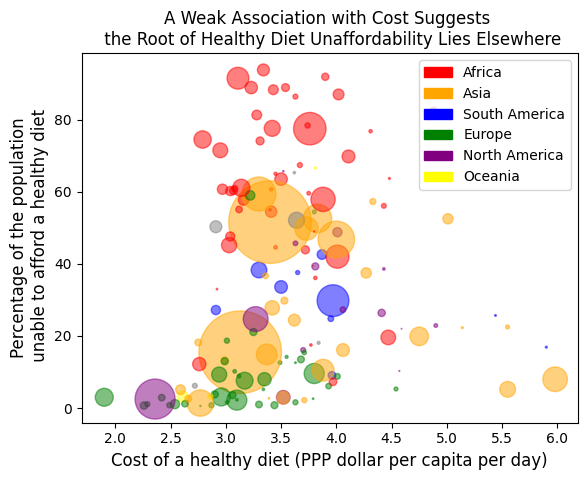

In [15]:
scatter=plt.scatter(scatter_plot_data["Cost of a healthy diet (PPP dollar per person per day)"],
            scatter_plot_data["Percentage of the population unable to afford a healthy diet (percent)"],
            marker=".", alpha=0.5, s=scatter_plot_data["Total Population"]/100000, c=scatter_plot_data["Color"]);
blue_patch = mpatches.Patch(color="blue", label="South America")
yellow_patch = mpatches.Patch(color="yellow", label="Oceania")
purple_patch = mpatches.Patch(color="purple", label="North America")
green_patch = mpatches.Patch(color="green", label="Europe")
orange_patch = mpatches.Patch(color="orange", label="Asia")
red_patch= mpatches.Patch(color="red", label="Africa")

plt.legend(handles=[red_patch, orange_patch, blue_patch, green_patch, purple_patch, yellow_patch])
plt.xlabel("Cost of a healthy diet (PPP dollar per capita per day)", fontsize=12)
plt.ylabel("Percentage of the population\n unable to afford a healthy diet", fontsize=12)
plt.title("A Weak Association with Cost Suggests \n the Root of Healthy Diet Unaffordability Lies Elsewhere",
         fontsize=12)
plt.show()

&nbsp;This scatter plot reinforces the earlier table’s conclusion that the unaffordability of healthy diets is driven more by domestic economic conditions than by global price levels. Countries across Europe, Asia, South America, and Africa all show healthy-diet costs in the domain of $3-4 PPP dollars per capita. However, a clear distinction can be observed in the vertical distribution of these continents. African countries occupy **nearly all** points above the 60% mark on the y-axis. Below them, the next highest cluster consists of Asian countries, followed by South American countries, and finally European countries at the bottom, where less than 20% of people are unable to afford a healthy diet. Given that Africa is among the most agricultural continents and Europe among the most industrialized, the plot suggests that **economic development** plays a key role in reducing the share of the population unable to afford healthy food.
<br> &nbsp; Additionally, the markersizes on the graph are representative of population size. Countries in Europe where a higher percentage of people can afford a healthy diet tend to have smaller population sizes. However, since small countries appear across the full range of values y-axis, economic development still seems to be a more important factor with a clearer correlation. 

## Conclusions
Through these visualizations and analyses, I was able to discover answers to two main aspects of my guiding theme: <br>

&nbsp;**1. The variables driving food cost:** From Figure 1, I learned that processing costs, on a broad scale, affect how much categories of food cost relative to each other. Figure 2 allowed me to notice that these relationships vary by continent as a result of geographic variables. Food supply is one of these variables, and by examining it closer in Figures 3 and 4.1-4.12, I found that in highly economically developed countries, food supply has a direct inverse correlation to food cost. <br>

&nbsp;**2. How food cost is related to affordability:** Additionally, I discovered that simply knowing the cost of a food is not enough information to ascertain whether that food is accessible to a general population. From Analysis 2, it became clear that higher costs of a diet do not exactly correspond to higher unaffordability. Figure 5 helped me better understand that affordability is more of a question of income levels and costs of living by region. World prices are unhelpful without information about a country's overall economic health. This particular conclusion is extremely important in the context of global issues such as scarcity and malnutrition. Some people believe that driving costs of food down is enough to solve these issues, but from this project, I realize that's only a short-term fix. The economic systems in developing countries must be strengthened so they can utilize their natural resources and benefit more from trade. This would help permanently drive down prices, stimulating economic growth that increases individuals' incomes and, in turn, their ability to purchase healthy foods. 

Opportunities for further data exploration: This report briefly touches upon trade networks and how they're a facet of economic development that affects the relationship between food supply and food cost. Further research might analyze how supply surpluses or deficits are reflected in trade metrics ex. import dependency ratios, export volumes. A future report could also include statistics on the cost of living and income in countries where food is very unaffordable, to determine if food unaffordability is part of a broader unaffordability problem. 

## Assumptions & Limitations
+ The CAHD dataset provided food costs grouped into six predefined categories. In contrast, the FAO food supply data did not have categories; I manually grouped the individual food items into similar categories for comparison. This report assumes that these groupings match across the two datasets, but because the exact foods included in each CAHD category aren't disclosed, some discrepancies between the two classification systems may exist.
+ Unfortunately, the datasets used were inconsistent in which years they had data on. Only 2021 had reliable data from all sources, and so all of the visualizations and analyses in this report pertain specifically to 2021. The report assumes that the state of global food affordability has not changed dramatically between 2021 and 2025.
+ The original CAHD data only included data on roughly 173 countries, and so this report and its applications are somewhat limited without data from all countries in the world. 


## Reflections
&nbsp;Finding the proper data for this project was very difficult for me. I based my topic around the World Bank CoAHD data, and so I had to adjust all imported datasets so that they utilized the same naming, size, year, and geographic areas. This made data wrangling very time consuming. Additionally, an obstacle that I encountered in my project was a lack of datasets with the exact food categories that I needed. I had found a previous,smaller, database with preexisting categories, but it didn't have data from any Africa, which was a continent of great importance in this analysis. As a result of the failure of this database, I had to find a much bigger database from FAOSTAT and cut it down to sort my needs. I manually sorted through more than 70 types of food and assigned them to the most appropriate food category to have accurate supply data. I tried to create a visualization with export volumes of different goods to look more at the trade angle of the question, but this proved too difficult logistically. Additionally, finding a way to create all 12 choropleth graphs with one cell was very difficult. I estimate that this project took me roughly 40 hours. 

#  Appendix 0 - Reviews of My Project
### A note on feedback incorporation:
After reading the peer reviews of my project, I chose to incorporate almost all of the feedback regarding more in-depth explanations, better connections back to my original theme, and placing long sections into the appendix. 
One piece of feedback that I chose not to incorporate was a suggestion to consolidate the choropleth maps; I believe that although there are many of them, each one has unique insights to offer.

## Review 1
#### Project writer name: Lindsey Prochot
#### Project writer email address: lindsey.prochot@yale.edu

#### Reviewer name: Kevin Hidalgo
#### Reviwer email address: kevin.hidalgo@yale.edu



### Summary

This project uses data visualizations to find different aspects of what makes a healthy diet unaffordable in certain countries. By looking at food supply, PPP dollars per day for different categories of a healthy diet, and taking a look at the correlations between these statistics and the reported unaffordability of the foods, this project takes a nuanced look at a healthy diet's affordability around the world. 



### 1. Overall strengths and weaknesses 

I found that this project painted a very convincing picture about affordability across the globe. I particularly liked figure 2 and I was incredibly impressed at the vibrant and complex graphs that visualized the data very effectively. My issue with some of the graphs is that I don't understand what the variables are measuring (i.e. kilograms per capita and supply and cost percentile), but assuming an intelligent audience, I don't see that as an issue to take points off for. Overall, the anaylsis and visualization of the statistics of food affordability were well thought out, thorough, and led to a great project.

### 2. Major revisions

- Nothing! 




### 3. Minor revisions 


- Maybe better colors could be used on the heatmap for visulization 4.1-4.12
- Some typos here and there, for example, in analysis 2: "there is a elationship" or " whic was a continent of great importance in this
analysis" in the reflection 
- Better titles on the graphs, I had to read the explanation of the data to understand some of it. This is fine, but more obviously labeled graphs would be good too.
- What is kilograms per capita? What is supply and cost percentile?


### 3. Rubric score

Introduction: 15/15
Data Cleaning: 12/12
Data Visualization: 23/23
Analyses: 23/23
Conclusions: 12/12
Review and Reflection: 12/12


#### Rubric items where points would be taken off if not addressed: 




### Total score:   97/97

### The rubric score here doesn't make sense to me. 15 + 12 + 23 + 23+ 12 + 12 is 97, not 90. Because of this, I will be grading on a 97 score.



## Review 2
#### Project writer name: lindsey Prochot
#### Project writer email address: lindsey.prochot@yale.edu

#### Reviewer name: Mercy Rono
#### Reviwer email address: mercy.rono@yale.edu



### Summary

Please write a one paragraph (~3-6 sentence) summary of the project here. You should summarize the main goals and findings of the project.

This project investigates the affordability of healthy diets across countries and continents, examining whether food costs are driven more by supply factors or by income and economic conditions.  The analysis finds that food category costs vary sharply across regions, that supply influences cost unevenly, and that income and economic development are stronger determinants of affordability than food prices alone, with African countries experiencing the highest unaffordability despite moderate prices.

### 1. Overall strengths and weaknesses

The project is clear, thorough, showing why the affordability of a healthy diet is an important global issue. It demonstrates extensive and technically strong data wrangling, integrating multiple datasets,including World Bank, FAOSTAT, population, and geographic data and harmonizing them for meaningful analysis. The analysis goes beyond descriptive statistics by using percentiles and a hypothesis test to quantify relationships and strengthen conclusions.

The project is extremely long and at times overly detailed, which makes the narrative harder to follow. Several visualizations,especially the 12 choropleth maps are rich but overwhelming, focusing on the most important maps or summarizing results in tables would make the main findings clearer. Additionally, The code could be streamlined by putting repeated steps into functions or moving them to the appendix, making the main text easier to read. Finally, although the project uses the year 2021 for good reason, acknowledging more explicitly how conclusions may or may not generalize over time would strengthen the discussion.


### 2. Major revisions

Add bullet points of items that you think should definitely be changed for the final submission of the project.


* Selectively show or summarize choropleth maps, combine visuals, or use summary tables to highlight key patterns.

* Streamline the code by organizing repetitive tasks into functions or placing long sections in the appendix

* Note limitations such as reliance on a single year

* Clarify any outlier data points (e.g., the Africa 274 kg/capita/day value). While you briefly mention it, providing additional context would make the insight more meaningful

### 3. Minor revisions


Add bullet points of items that are more minor, but that would be good to change for the final submission of the project.

* Improve naming consistency (capitalization of food categories, “Oils and Fat” vs “Oils and Fats,” etc.).

* Standardize capitalization (“Supply Percentile” vs. “supply percentile”) across dataframes.

* Add a short “future work” or “next steps” sentence in the conclusion


### 3. Rubric score

Please write a score for the project based on the project rubric that is on the top of the class Canvas page (where all the project related information is listed). For any items where there would be points deducted, please cut and paste a bullet point for that item in the "Items for points take off" section below.


#### Rubric items where points would be taken off if not addressed:



### Total score:   87/90






## Review 3

#### Project writer name: Lindsey Prochot
#### Project writer email address: lindsey.prochot@yale.edu

#### Reviewer name: Zachary Cheng
#### Reviwer email address: zachary.cheng@yale.edu



### Summary



This project explores the global cost and affordability of healthy diets by comparing food prices and food supply across continents and individual countries.
The writer uses data from the World Bank and FAOSTAT to study how different food categories contribute to total diet costs and how affordability varies with economic development.


### 1. Overall strengths and weaknesses 

A major strength of this project is the careful use of several types of visualizations to explain a multi layered topic. The stacked bar chart and the heatmap work well together to show how food supply and food prices vary by continent. The choropleth maps are impressive in scale and make it easy to compare supply and cost percentiles across countries. I also found the hypothesis test convincing, since the null distribution was constructed clearly and the result supports the visual patterns seen earlier in the report. The discussion of affordability is thoughtful and supported by both the table and the scatter plot.

One weakness is that some parts of the report are dense and would benefit from clearer guidance for the reader. For instance, the introduction mentions several research questions, but the later sections could relate more directly to each question.

### 2. Major revisions

Connect each major visualization more clearly to the main research questions.

Add more interpretation to the choropleth maps so readers understand the patterns.


### 3. Minor revisions 

Improve axis labels, titles, and captions for greater clarity.

Clarify transitions between figures to create a smoother narrative.


### 3. Rubric score


Some graphs need clearer written explanations of insights.

Analyses section would benefit from additional interpretation and more explicit links to the research question.


### Total score:   88/90





# Appendix 1 - Additional Data Wrangling

### Appendix 1.1

In [ ]:
##Creating a dataframe (continent_categories2) of countries and their corresponding continents so that countries can be grouped
continent_categories= pd.read_csv("countries_by_continents.csv")

continent_categories2=continent_categories.sort_values(by='Country')

##Creating a dataframe (general_grouped_w_continents) that has the median cost per food category for each continent
##It also has the median number of people unable to afford a healthy diet
##It also has the median percentage of the population unable to afford a healthy diet 
general_grouped_w_continents=general_grouped_data.reset_index()
general_grouped_w_continents=general_grouped_w_continents.merge(continent_categories2, how="left",
                                                    left_on="REF_AREA_LABEL", right_on="Country")
general_grouped_w_continents=general_grouped_w_continents.drop(columns=["Country"])

##Creating a dataframe (food_categories_stacked) 
##It's essentially just general_grouped_w_continents but filtered down to only have medians for the food categories
food_categories_data=general_grouped_w_continents[["Cost of animal source foods", "Cost of fruits",
                                                   "Cost of legumes, nuts and seeds", "Cost of oils and fats",
                                                   "Cost of starchy staples", "Cost of vegetables", "Continent"]]


### Appendix 1.2

In [ ]:
new_blank_supply_df["Animal Source Foods Supply"] = supply_data_pivot[["Aquatic Animals, Others", "Bovine Meat",
                                                                          "Demersal Fish","Eggs", "Freshwater Fish","Marine Fish, Other",
                                                                          "Meat, Aquatic Mammals","Meat, Other","Mutton & Goat Meat",
                                                                          "Pelagic Fish", "Pigmeat","Poultry Meat"]].sum(axis=1)                                                                 
                                                               
new_blank_supply_df["Fruits Supply"] = supply_data_pivot[["Apples and products","Bananas","Coconuts - Incl Copra","Dates","Fruits, other",
                                                              "Grapefruit and products", "Grapes and products (excl wine)",
                                                              "Lemons, Limes and products","Olives (including preserved)",
                                                              "Oranges, Mandarines","Pineapples and products","Plantains",
                                                            "Tomatoes and products"]].sum(axis=1)
                                                              
                                                             
new_blank_supply_df["Legumes, nuts and seeds Supply"] = supply_data_pivot[["Beans","Groundnuts","Nuts and products", 
                                                                             "Pulses, Other and products","Soyabeans"]].sum(axis=1)
                                                                                                                                                 
new_blank_supply_df["Oils and Fat Supply"] = supply_data_pivot[["Butter, Ghee","Coconut Oil",
                                                                    "Cottonseed", "Cottonseed Oil","Cream",
                                                                    "Fats, Animals, Raw","Fish, Body Oil","Fish, Liver Oil",
                                                                   "Groundnut Oil","Maize Germ Oil","Milk - Excluding Butter",
                                                                   "Oilcrops Oil, Other","Olive Oil","Palm Oil","Palm kernels",
                                                                   "Palmkernel Oil","Rape and Mustard Oil", "Rape and Mustardseed",
                                                                    "Sesame seed", "Sesameseed Oil", "Soyabean Oil",
                                                                    "Sunflower seed"]].sum(axis=1)                                    
                                                                 
new_blank_supply_df["Starchy staples Supply"] = supply_data_pivot[["Barley and products","Cassava and products","Cereals, other","Maize and products",
                                                                      "Millet and products","Oats","Potatoes and products", "Rice and products",
                                                                       "Ricebran Oil","Roots, Other","Rye and products","Sorghum and products",
                                                                       "Sweet potatoes","Wheat and products", "Yams"]].sum(axis=1)
                                                                                                                                           
new_blank_supply_df["Vegetables Supply"] = supply_data_pivot[["Aquatic Plants","Onions","Peas", "Vegetables, other"]].sum(axis=1)
name_map = {"Burkina Faso": "Burkina","Cabo Verde": "Cape Verde","Côte d'Ivoire": "Cote d'Ivoire",
            "Democratic Republic of the Congo": "Democratic Republic of Congo","Republic of Korea": "South Korea",
            "Republic of Moldova": "Moldova","Russian Federation": "Russia", "Syrian Arab Republic": "Syria",
            "United Republic of Tanzania": "Tanzania", "Türkiye": "Turkey", "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
            "United States of America": "United States", "Viet Nam": "Vietnam", "China, Hong Kong SAR": "Hong Kong",
            "Bolivia (Plurinational State of)": "Bolivia","Iran (Islamic Republic of)": "Iran", "Lao People's Democratic Republic": "Laos",
            "Netherlands (Kingdom of the)": "Netherlands","United Arab Emirates": "United Arab Emirates"}
new_blank_supply_df=new_blank_supply_df.rename(index=name_map)




## Appendix 1.3

In [ ]:
##I am now extracting out supply and cost pairs per category to create individual dataframes
##I do this so the relationship between supply percentiles and cost percentiles can be looked at per food category
protein_df=merged_percentiles[["Animal Source Foods Supply percentile", "Cost of animal source foods percentile"]]
rename_dictionary={"Animal Source Foods Supply percentile":"Supply Percentile", "Cost of animal source foods percentile": "Cost Percentile"}
protein_df=protein_df.rename(columns=rename_dictionary)

fruits_df=merged_percentiles[["Fruits Supply percentile", "Cost of fruits percentile"]]
rename_dictionary={"Fruits Supply percentile":"Supply Percentile", "Cost of fruits percentile": "Cost Percentile"}
fruits_df=fruits_df.rename(columns=rename_dictionary)

legumes_df=merged_percentiles[["Legumes, nuts and seeds Supply percentile", "Cost of legumes, nuts and seeds percentile"]]
rename_dictionary={"Legumes, nuts and seeds Supply percentile":"Supply Percentile", "Cost of legumes, nuts and seeds percentile": "Cost Percentile"}
legumes_df=legumes_df.rename(columns=rename_dictionary)

fats_df=merged_percentiles[["Oils and Fat Supply percentile", "Cost of oils and fats percentile"]]
rename_dictionary={"Oils and Fat Supply percentile":"Supply Percentile", "Cost of oils and fats percentile": "Cost Percentile"}
fats_df=fats_df.rename(columns=rename_dictionary)

starches_df=merged_percentiles[["Starchy staples Supply percentile", "Cost of starchy staples percentile"]]
rename_dictionary={"Starchy staples Supply percentile":"Supply Percentile", "Cost of starchy staples percentile": "Cost Percentile"}
starches_df=starches_df.rename(columns=rename_dictionary)

vegetables_df=merged_percentiles[["Vegetables Supply percentile", "Cost of vegetables percentile"]]
rename_dictionary={"Vegetables Supply percentile":"Supply Percentile", "Cost of vegetables percentile": "Cost Percentile"}
vegetables_df=vegetables_df.rename(columns=rename_dictionary)

##This function turns the food category dataframes from earlier into geopandas dataframes
def create_geodatas(df):
    choropleth = df.merge(world_coordinates, how="inner", left_on="REF_AREA_LABEL", right_index=True)
    geodata = gpd.GeoDataFrame(choropleth, geometry="geometry")
    return geodata
protein_choropleth_geodata = create_geodatas(protein_df)
fruits_choropleth_geodata = create_geodatas(fruits_df)
legumes_choropleth_geodata = create_geodatas(legumes_df)
fats_choropleth_geodata = create_geodatas(fats_df)
starches_choropleth_geodata = create_geodatas(starches_df)
vegetables_choropleth_geodata = create_geodatas(vegetables_df)

##Loading in a dataset with geographical coordinates 
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

##Creating a dataframe (world_coordinates) that has country names and their geographical coordinates
##I had to rename some of the country names for merging later
name_corrections = {"United States of America": "United States", "United Republic of Tanzania": "Tanzania",
                    "Ivory Coast": "Cote d'Ivoire", "eSwatini": "Eswatini","Republic of Serbia": "Serbia",
                    "The Bahamas": "Bahamas", "Democratic Republic of the Congo": "Congo, Dem. Rep.", 
                    "Republic of the Congo": "Congo, Rep.", "East Timor": "Timor-Leste", "Russia": "Russian Federation",
                    "South Korea": "Korea, Rep.", "North Korea": "Korea, Dem. People's Rep.", "Laos": "Lao PDR",
                    "Iran": "Iran, Islamic Rep.", "Syria": "Syrian Arab Republic","Brunei": "Brunei Darussalam"}
world=world.set_index("ADMIN")
world = world.rename(index=name_corrections)
world_coordinates=world[["geometry"]]


## Appendix 1.4

In [ ]:
population_data_2021=population_data_2021.drop(columns={"Net migration [SM.POP.NETM]", "Rural population [SP.RUR.TOTL]",
                                                        "Urban population [SP.URB.TOTL]", "Time", "Time Code"})
population_data_2021 = population_data_2021.drop(population_data_2021.columns[2], axis=1)
population_data_2021 = population_data_2021.drop(index=[0])
population_data_2021 = population_data_2021.drop(index=[218,219,220,221,222])
population_data_2021=population_data_2021.rename(columns={"Population, total [SP.POP.TOTL]":"Total Population"})
final_population_data_2021=population_data_2021.set_index("Country Name")

##Renaming some countries so final_population_data_2021 is compatible for merging with the wide_diet_data database
final_population_data_2021=final_population_data_2021.rename(index={"Viet Nam":"Vietnam", "Bahamas, The": "Bahamas",
    "Congo, Rep.":"Congo", "Congo, Dem. Rep.":"Democratic Republic of Congo","Brunei Darussalam":"Brunei",
    "Burkina Faso": "Burkina", "Cabo Verde":"Cape Verde", "Egypt, Arab Rep.":"Egypt", "Gambia, The":"Gambia",
    "Hong Kong SAR, China":"Hong Kong", "Korea, Rep.":"South Korea", "Iran, Islamic Rep.":"Iran","Kyrgyz Republic":"Kyrgyzstan",
    "Lao PDR":"Laos", "Russian Federation":"Russia", "Slovak Republic":"Slovakia", "St. Kitts and Nevis":"Saint Kitts and Nevis",
    "St. Lucia":"Saint Lucia", "St. Vincent and the Grenadines":"Saint Vincent and the Grenadines", "Syrian Arab Republic":"Syria",
    "Taiwan, China":"Taiwan","Turkiye":"Turkey", "Korea, Dem. People's Rep.":"North Korea"})

In [17]:
%%capture

!quarto render rearranged_final_project.ipynb --cache-refresh --to pdf 